# Packages

In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
import scipy.stats as stats
from scipy import signal
from scipy.signal import find_peaks

# Import Data and Wrangle It

In [3]:
data = pd.read_csv('Previous_data.csv') #load data
print(data.columns) #print columns so i can copy and past them because they are not coding friendly

#sap flow data wrangling
sf = xr.DataArray(data['Corrected Out (cm/hr)'][1:673]) #sap flow data, cut to where it ends
time = pd.to_datetime(data['Datesf'][1:673] + " " + data['Timesf'][1:673], dayfirst=True) #date and time columns are joined
time_seconds = (time-np.min(time))/np.timedelta64(1,'s') #convert data time to seconds

#water level data wrangling
water_level = xr.DataArray(data['Water Level'][126:4153])
time_water = pd.to_datetime(data['Datelvl'][126:4153]+ " " + data['Timelvl'][126:4153], dayfirst=True)
time_water_seconds = (time_water-np.min(time))/np.timedelta64(1,'s')

#temperature data wrangling
temp = xr.DataArray(data['Temperature'][1:593])
time_temp = pd.to_datetime(data['Date time  temp'][1:593])
time_temp_seconds = (time_temp-np.min(time))/np.timedelta64(1,'s')

#water data for scatter plots
uncut_level= pd.DataFrame(water_level) #convert to dataframe so that iloc works
cut_lvl = uncut_level.iloc[::6] #sf is every 30 min, water level is every 5 min,  so i must take every 6th water level cell to have them be the same length

Index(['Datelvl', 'Timelvl', 'Water Level', 'Datesf', 'Timesf',
       'Corrected Out (cm/hr)', 'Date time hum', 'Humidity', 'Date time  temp',
       'Temperature'],
      dtype='str')


C:\Users\Anast\AppData\Local\Temp\ipykernel_19964\2916364960.py:16: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  time_temp = pd.to_datetime(data['Date time  temp'][1:593])


# Sap Flow and Water Graph

C:\Users\Anast\AppData\Local\Temp\ipykernel_19964\3937242254.py:20: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  datasf = pd.to_datetime(data['Datesf'][1:673])


([<matplotlib.axis.XTick at 0x1f84590e350>,
 [Text(0.0, 0, '01-18'),
  Text(90000.0, 0, '01-19'),
  Text(180000.0, 0, '01-20'),
  Text(270000.0, 0, '01-21'),
  Text(360000.0, 0, '01-22'),
  Text(450001.0, 0, '01-23'),
  Text(540001.0, 0, '01-24'),
  Text(630001.0, 0, '01-25'),
  Text(720001.0, 0, '01-26'),
  Text(810001.0, 0, '01-27'),
  Text(900001.0, 0, '01-28'),
  Text(990000.0, 0, '01-29'),
  Text(1080001.0, 0, '01-30'),
  Text(1170000.0, 0, '01-31')])

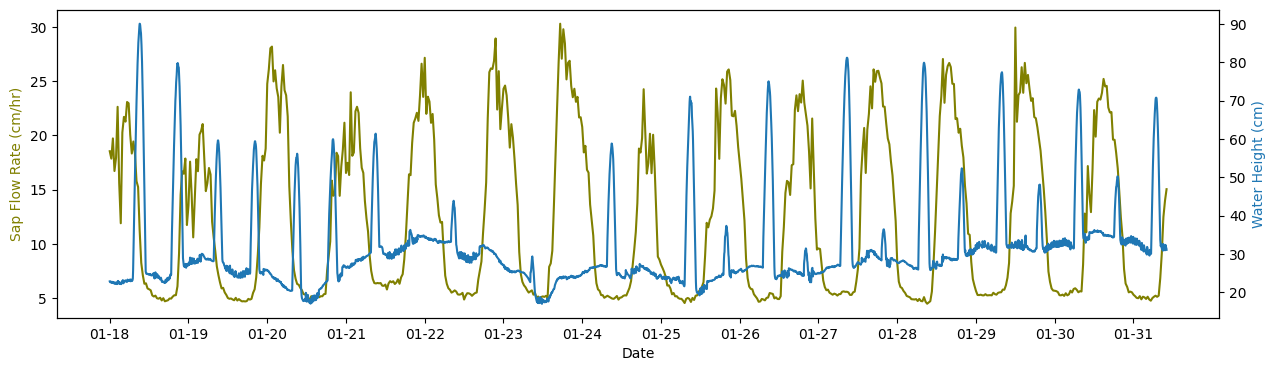

In [4]:
plt.rcParams['figure.figsize'] = [15, 4] #make x axis longer and graph more readable
fig, ax1 = plt.subplots()
#sap flow line
color = 'olive' 
ax1.set_xlabel('Date')
ax1.set_ylabel('Sap Flow Rate (cm/hr)', color=color)
ax1.plot(time_seconds, sf, color=color)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()  # make a second y axis that shares the same x-axis
#water level
color = 'tab:blue'
ax2.set_ylabel('Water Height (cm)', color=color) 
ax2.plot(time_water_seconds, water_level, color=color)
ax2.tick_params(axis='y')

tick_positions = time_seconds[::50]# tick positions

# Convert sap flow time data to datetime
datasf = pd.to_datetime(data['Datesf'][1:673])
tick_labels = datasf.dt.strftime('%m-%d')[::50] #force date ticks while the actual data is seconds
plt.xticks(tick_positions, tick_labels)

# Linear Regression

In [5]:
def get_r2(x,y): #regression function
    polyfit = np.polyfit(x,y,1)
    x = np.asarray(x).flatten() #added so that I don't have numpy - pandas collision with arrays and dataframes
    y = np.asarray(y).flatten()
    y_predicted = np.polyval(polyfit,x)
    residuals = y-y_predicted
    return 1-np.sum(residuals**2)/np.sum((y-np.mean(y))**2)

get_r2(sf, cut_lvl) #check it works

np.float64(0.02971362054848281)

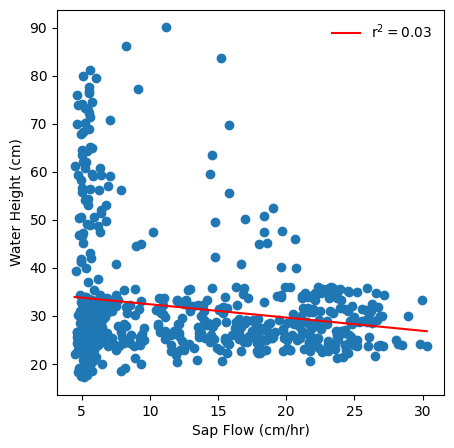

In [7]:
sf = np.asarray(sf).flatten() 
cut_lvl = np.asarray(cut_lvl).flatten() #arrays flattened so that python believes me that they are the same dimension

plt.rcParams['figure.figsize'] = [5, 5] #make plot a square
plt.scatter(sf,cut_lvl) #create scatter plot

sf_vs_wl_polyfit = np.polyfit(sf,cut_lvl,1) #fit a line to the data
tempx = np.linspace(np.min(sf),np.max(sf)) #take evenly space numbers
plt.plot(tempx,np.polyval(sf_vs_wl_polyfit,tempx),'r',label='r$^2=%.2f$'%(get_r2(sf,cut_lvl))) #plot regression line ontop of scatter plot, with label

plt.xlabel('Sap Flow (cm/hr)')
plt.ylabel('Water Height (cm)') #axis labels
plt.legend(frameon=False) #no frame on legend

# FFTs

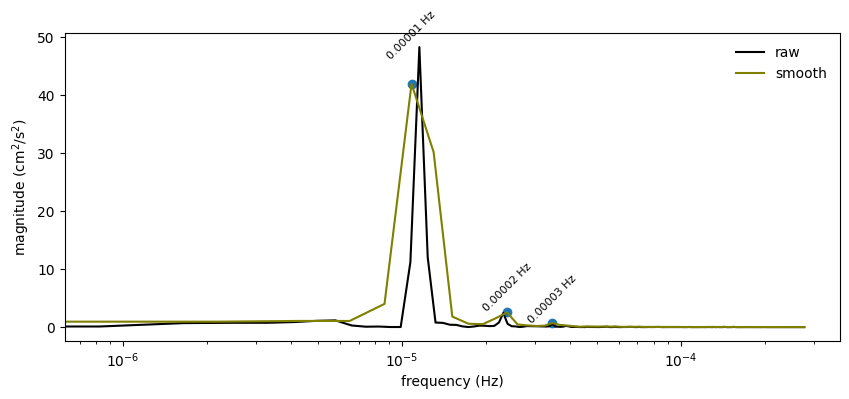

In [21]:
#FFT of sap flow
f, PUU = signal.welch(sf,1/np.diff(time_seconds)[0],nperseg=len(time_seconds),scaling='spectrum') #raw line of frequency spectrum
f_smooth, PUU_smooth = signal.welch(sf,1/np.diff(time_seconds)[0], scaling='spectrum')#smoothed line, with less sampling
peak_sf,_=find_peaks(PUU_smooth, prominence=PUU_smooth.max()*0.005) #find those three peaks, parameters found with trial and error
#plot them!
plt.rcParams['figure.figsize'] = [10, 4] #make x axis longer 
plt.plot(f, PUU,'k',label='raw') #raw line
plt.plot(f_smooth, PUU_smooth,label='smooth', c='olive') #smooth line
plt.xscale('log') #makes it easier to read
plt.scatter(f_smooth[peak_sf], PUU_smooth[peak_sf], color='tab:blue')#mark peaks
for i in peak_sf: #label peaks
    plt.text(
        f_smooth[i],
        PUU_smooth[i] * 1.1,   # put label above the peak
        f"{f_smooth[i]:.5f} Hz", #actual label
        ha='center', #higher
        fontsize=8,
        rotation=45
    )
plt.xlabel('frequency (Hz)')
plt.ylabel('magnitude (cm$^2$/s$^2$)')
plt.legend(loc=0,frameon=False)

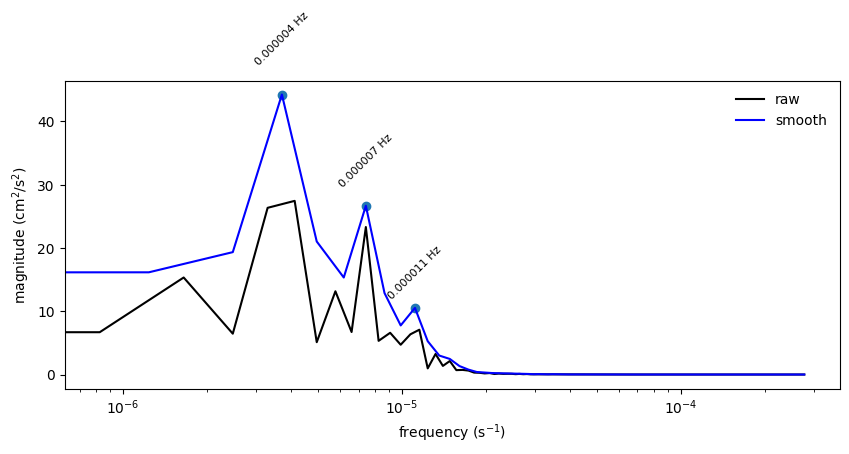

In [34]:
#FFT with water level
w, wPUU = signal.welch(water_level,1/np.diff(time_seconds)[0],nperseg=len(time_seconds),scaling='spectrum') #raw line
w_smooth, wPUU_smooth = signal.welch(water_level,1/np.diff(time_seconds)[0], nperseg=len(time_seconds)//1.5, scaling='spectrum') #smooth line, increased resolution from sap flow FFT smoothing
peak_w,_=find_peaks(wPUU_smooth, prominence=wPUU_smooth.max()*0.05) #find the peaks,
#plotted
plt.rcParams['figure.figsize'] = [10, 4] #make x axis longer 
plt.plot(w, wPUU,'k',label='raw')
plt.plot(w_smooth, wPUU_smooth,label='smooth', c='blue') 
plt.xscale('log')
#plt.yscale('log')
plt.scatter(w_smooth[peak_w], wPUU_smooth[peak_w], color='tab:blue')#mark peaks
for i in peak_w: #label peaks
    plt.text(
        w_smooth[i],
        wPUU_smooth[i] * 1.1,   # put label above the peak
        f"{w_smooth[i]:.6f} Hz",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45
    )
plt.xlabel('frequency (s$^{-1}$)')
plt.ylabel('magnitude (cm$^2$/s$^2$)')
plt.legend(loc=0,frameon=False)

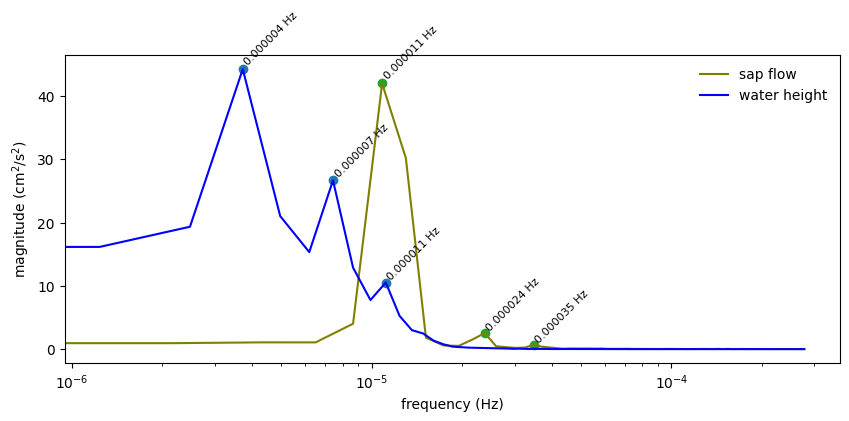

In [40]:
#only smooth lines with peaks labelled of both sap flow and water level
plt.rcParams['figure.figsize'] = [10, 4] #make x axis longer 

plt.plot(f_smooth, PUU_smooth,label='sap flow', c='olive') #plot sap flow smooth lines
plt.xscale('log') #x axis in log for readability
plt.scatter(f_smooth[peak_sf], PUU_smooth[peak_sf], color='tab:green')#mark sap flow peaks
for i in peak_sf: #label sap flow peaks
    plt.text(
        f_smooth[i],
        PUU_smooth[i] * 1.01,   #label distance from peak
        f"{f_smooth[i]:.6f} Hz", #ensure same sig figs
        va='bottom',
        fontsize=8,
        rotation=45
    )
    
plt.plot(w_smooth, wPUU_smooth,label='water height', c='blue') #plot water height smooth lines    
plt.scatter(w_smooth[peak_w], wPUU_smooth[peak_w], color='tab:blue')#mark water height peaks
for i in peak_w: #label water height peaks
    plt.text(
        w_smooth[i],
        wPUU_smooth[i] * 1.01, 
        f"{w_smooth[i]:.6f} Hz",
        va='bottom',
        fontsize=8,
        rotation=45
    )
    
plt.xlabel('frequency (Hz)')
plt.ylabel('magnitude (cm$^2$/s$^2$)')
plt.legend(loc=0,frameon=False)